## Sample vs. Population

<b>Population</b>
* A collection of all items of interest
* AKA: parameters
* Denoted by <i>N</i>
* Properly accounting for an entire population is difficult
  * Ex: Studying entire population of a university's student
    * Some students are remote, others part-time, etc.
  * They are hard to observe and contact

<b>Sample</b>
* A subset of the population
* AKA: statistics
* Denoted by <i>n</i>
* Less time consuming and costly to gather than a population
  * Easier to observe and contact
* A sample must be both `random` <b>and</b> `representative` for it's insights to be deemed accurate
  * Ex: Going to a restaurant on campus to survey students
  * Randomness
    * A random sample is collected when each member of the sample is chosen from the population strictly by chance
    * This is <b><i>not</i></b> indicative of a random sample since we are excluding all other students not present in the restaurant
  * Representativeness
    * A representative sample is a subset of the population that accurately reflects the members of the entire population
    * This is <b><i>not</i></b> indicative of a representative sample since it represents only NYU students who eat in that specific restaurant

## Fundamentals of Descriptive Statistics

<b>Various Types of Data</b>
* Types of Data
  * Categorical
    * Describes categories or groups
      * Ex: (car brands, yes/no questions, etc.)
  * Numerical
    * Represents numbers, and can further be described into two subsets
    * Discrete
      * Can be counted in a finite matter
        * Ex: The number of children someone has (1, 2, etc.)
      * Opposite of continous data
    * Continuous
      * A number than can take on any value
        * Ex: A person's weight (150.3, 123.56, etc.)

<b>Levels of Measurement</b>
* Qualitative
  * Nominal
    * Are not numbers, and can't be ordered (summer is not a higher rank than winter)
      * Ex: The seasons of the year (autumn, winter, spring, summer)
  * Ordinal
    * Numbers and categories that follow a strict order
      * Ex: Rating your lunch (disgusting, unappetizing, neutral, tasty, delicious)
* Quantitative
  * Represented by numbers
  * Interval
    * Does not have a true 0
      * Ex: Temperature: 40 degrees is not twice as hot as 20 degrees, since 0 degrees is not a true 0
  * Ratio
    * Has a true 0
    * The name comes from the fact that they can represent ratios of things
      * Ex: If I have 2 apples, and someone else has 6; they would have 3 times as many as I do

In [20]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# Set random seed for reproducibility
np.random.seed(42)

# Number of records
n = 100

data = {
    "ID": range(1, n + 1),
    "Age": np.random.randint(18, 70, size=n),
    "Gender": np.random.choice(["Male", "Female", "Other"], size=n),
    "Income": np.round(np.random.normal(60000, 15000, size=n), 2),
    "Signup_Date": [datetime.today() - timedelta(days=random.randint(0, 365*5)) for _ in range(n)],
    "Subscribed": np.random.choice([True, False], size=n),
    "Department": np.random.choice(["Sales", "Engineering", "HR", "Marketing", "Finance"], size=n),
    "Satisfaction_Score": np.random.randint(1, 11, size=n),  # scale 1-10
    "Comments": np.random.choice([
        "Great service", "Needs improvement", "Very satisfied", "Unhappy", "Okay experience", None
    ], size=n),
    "Bonus_Percentage": np.round(np.random.uniform(0.05, 0.20, size=n), 2)
}

df = pd.DataFrame(data)
df.head()

,ID,Age,Gender,Income,Signup_Date,Subscribed,Department,Satisfaction_Score,Comments,Bonus_Percentage
0,1,56,Male,54859.28,2024-03-27 21:04:18.513540,True,Finance,9,None,0.19
1,2,69,Male,47965.84,2021-08-02 21:04:18.513540,True,Sales,8,Okay experience,0.14
2,3,46,Male,57580.71,2022-02-13 21:04:18.513540,True,Engineering,3,None,0.16
3,4,32,Other,66060.76,2024-03-18 21:04:18.513540,False,Engineering,1,Needs improvement,0.16
4,5,60,Male,88292.79,2020-11-30 21:04:18.513540,False,Sales,3,Unhappy,0.11


In [21]:
#Frequency distribution table, showing number of values for each category
df['Department'].value_counts().sort_values(ascending=False)

Department
Finance        27
Engineering    25
Marketing      18
Sales          17
HR             13
Name: count, dtype: int64

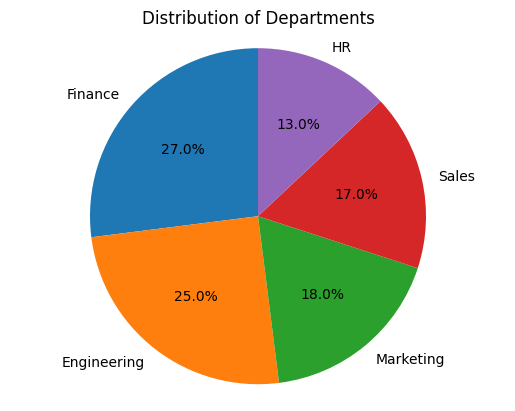

In [22]:
#Relative frequency shows the percentages each category holds in reference to total (totaling to 100%)

import matplotlib.pyplot as plt

# Get counts of each department
dept_counts = df['Department'].value_counts()

# Create the pie chart
plt.pie(
    dept_counts, 
    labels=dept_counts.index, 
    autopct='%1.1f%%', 
    startangle=90
)

plt.title('Distribution of Departments')
plt.axis('equal')  # Equal aspect ratio ensures the pie is a circle
plt.show()

<Axes: xlabel='Income', ylabel='Count'>

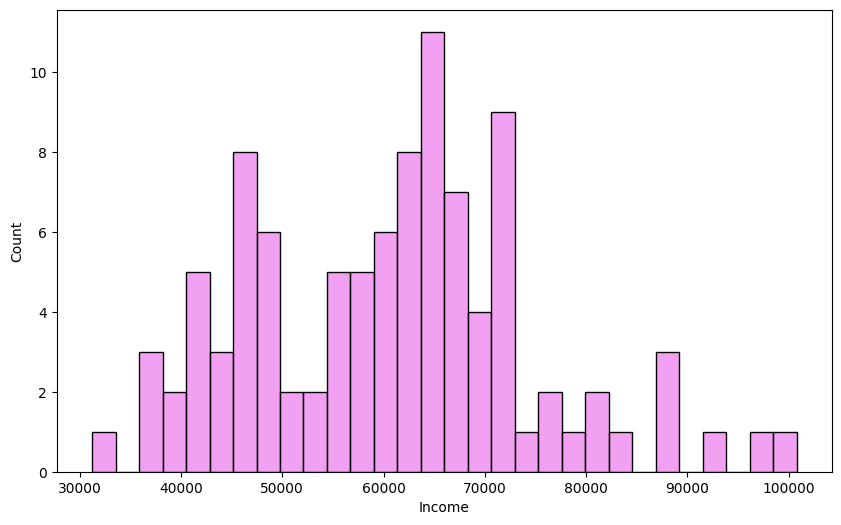

In [23]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Income', bins=30, color='violet', edgecolor='black')

<Axes: xlabel='Age', ylabel='Income'>

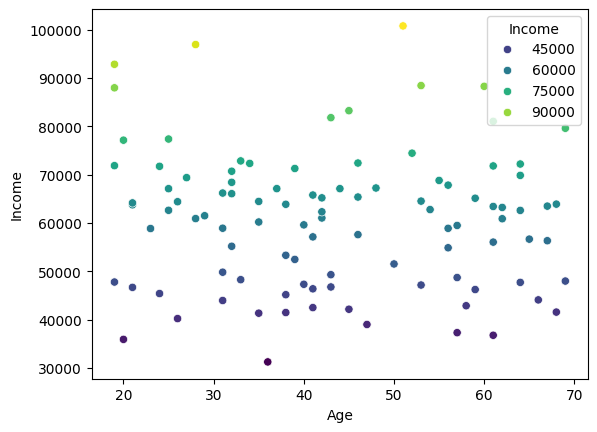

In [24]:
sns.scatterplot(data=df, x='Age', y='Income', hue='Income', palette='viridis')

## Measures of Central Tendency